# Phase Diagram of the Cluster-Ising Model

**Hamiltonian**: $H(\lambda) = -\sum_j \sigma^x_{j-1}\sigma^z_j\sigma^x_{j+1} + \lambda \sum_j \sigma^y_j\sigma^y_{j+1}$

**QPT at** $\lambda = 1$: Cluster phase ($\lambda < 1$, string order $O_z$) $\leftrightarrow$ Ising phase ($\lambda > 1$, staggered magnetization $m_y$)

This notebook sweeps $\lambda$ and compares **Exact analytical**, **ED**, and **DMRG** results for:
1. Ground-state energy $E_0/L$
2. Energy gap $\Delta$
3. Staggered magnetization $m_y$
4. String order parameter $O_z$
5. Residual entanglement $\tau$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import sys, os

# Add project root to path
sys.path.insert(0, os.path.abspath('..'))

%matplotlib inline
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 6)})

## 0. Parameters (adjust here)

In [2]:
# === Sweep parameters ===
lam_min, lam_max, n_lam = 0.01, 3.0, 60    # lambda range
lam_values = np.linspace(lam_min, lam_max, n_lam)

# === ED parameters ===
# L=10: ~2s total, L=12: ~20s, L=14: ~5min
L_ed = 12          # system size for ED (keep <= 14)
bc_ed = 'open'     # 'open' or 'periodic'

# === DMRG parameters ===
run_dmrg = True    # Set False to skip DMRG (faster)
L_dmrg = 40        # system size for DMRG (40: ~1min/point, 60: ~2min/point)
chi_max = 100      # bond dimension
n_lam_dmrg = 20    # fewer points for DMRG (slower)
lam_dmrg = np.linspace(lam_min, lam_max, n_lam_dmrg)

print(f"Exact: thermodynamic limit, {n_lam} points")
print(f"ED: L={L_ed}, bc={bc_ed}, {n_lam} points")
if run_dmrg:
    print(f"DMRG: L={L_dmrg}, chi_max={chi_max}, {n_lam_dmrg} points")

Exact: thermodynamic limit, 60 points
ED: L=12, bc=open, 60 points
DMRG: L=40, chi_max=100, 20 points


## 1. Exact Analytical Solution (thermodynamic limit)

In [3]:
from cluster_ising.models.exact_solution import (
    energy_vs_lambda,
    order_parameters_vs_lambda,
    energy_gap,
    ground_state_energy_density,
)

# Exact results (thermodynamic limit)
E_exact = energy_vs_lambda(lam_values)
ops_exact = order_parameters_vs_lambda(lam_values)
gap_exact = np.array([energy_gap(l) for l in lam_values])

print(f"E_0/L at lambda=0: {E_exact[0]:.6f} (exact: -1.0)")
print(f"Gap at lambda=1.0: {energy_gap(1.0):.2e} (exact: 0)")
print(f"m_y at lambda=2.0: {ops_exact['m_y'][lam_values >= 2.0][0]:.6f}")

E_0/L at lambda=0: -1.000025 (exact: -1.0)
Gap at lambda=1.0: 0.00e+00 (exact: 0)
m_y at lambda=2.0: 0.901772


## 2. Exact Diagonalization

In [4]:
from cluster_ising.solvers.ed_solver import run_ed
from cluster_ising.observables.order_parameters import (
    staggered_magnetization_y,
    string_order_z,
    residual_entanglement_tau,
)

E_ed = np.zeros(n_lam)
my_ed = np.zeros(n_lam)
Oz_ed = np.zeros(n_lam)
tau_ed = np.zeros(n_lam)
gap_ed = np.zeros(n_lam)

for i, lam in enumerate(lam_values):
    result = run_ed({'L': L_ed, 'lam': lam, 'bc': bc_ed}, n_states=4)
    psi = result.state
    E_ed[i] = result.energy_per_site
    my_ed[i] = staggered_magnetization_y(psi, L_ed, 'vector')
    Oz_ed[i] = string_order_z(psi, L_ed, 'vector')
    tau_ed[i] = residual_entanglement_tau(psi, L_ed, 'vector')
    # Gap from first two eigenvalues
    evals = result.metadata['eigenvalues']
    gap_ed[i] = evals[1] - evals[0] if len(evals) > 1 else 0.0

print(f"ED done: {n_lam} lambda values, L={L_ed}")

ED done: 60 lambda values, L=12


## 3. DMRG

In [5]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

E_dmrg = None
my_dmrg = None
Oz_dmrg = None
tau_dmrg = None

if run_dmrg:
    from cluster_ising.solvers.dmrg_solver import run_dmrg as _run_dmrg
    from tqdm.auto import tqdm

    E_dmrg = np.zeros(n_lam_dmrg)
    my_dmrg = np.zeros(n_lam_dmrg)
    Oz_dmrg = np.zeros(n_lam_dmrg)
    tau_dmrg = np.zeros(n_lam_dmrg)

    dmrg_params = {
        'trunc_params': {'chi_max': chi_max, 'svd_min': 1e-10},
        'mixer': True,
        'mixer_params': {'amplitude': 1e-5, 'decay': 1.5, 'disable_after': 30},
        'max_sweeps': 50,
        'max_E_err': 1e-10,
        'max_S_err': 1e-6,
    }

    for i, lam in enumerate(tqdm(lam_dmrg, desc='DMRG sweep')):
        model_params = {
            'L': L_dmrg,
            'lam': lam,
            'bc_MPS': 'finite',
            'conserve': 'parity',
        }
        result = _run_dmrg(model_params, dmrg_params)
        psi = result.state
        E_dmrg[i] = result.energy_per_site
        my_dmrg[i] = staggered_magnetization_y(psi, L_dmrg, 'mps')
        Oz_dmrg[i] = string_order_z(psi, L_dmrg, 'mps')
        tau_dmrg[i] = residual_entanglement_tau(psi, L_dmrg, 'mps')

    print(f"DMRG done: {n_lam_dmrg} lambda values, L={L_dmrg}, chi={chi_max}")
else:
    print("DMRG skipped (set run_dmrg=True to enable)")

DMRG sweep:   0%|          | 0/20 [00:00<?, ?it/s]

final DMRG state not in canonical form up to norm_tol=1.00e-05: norm_err=4.15e-05


DMRG done: 20 lambda values, L=40, chi=100


## 4. Comparison Plots

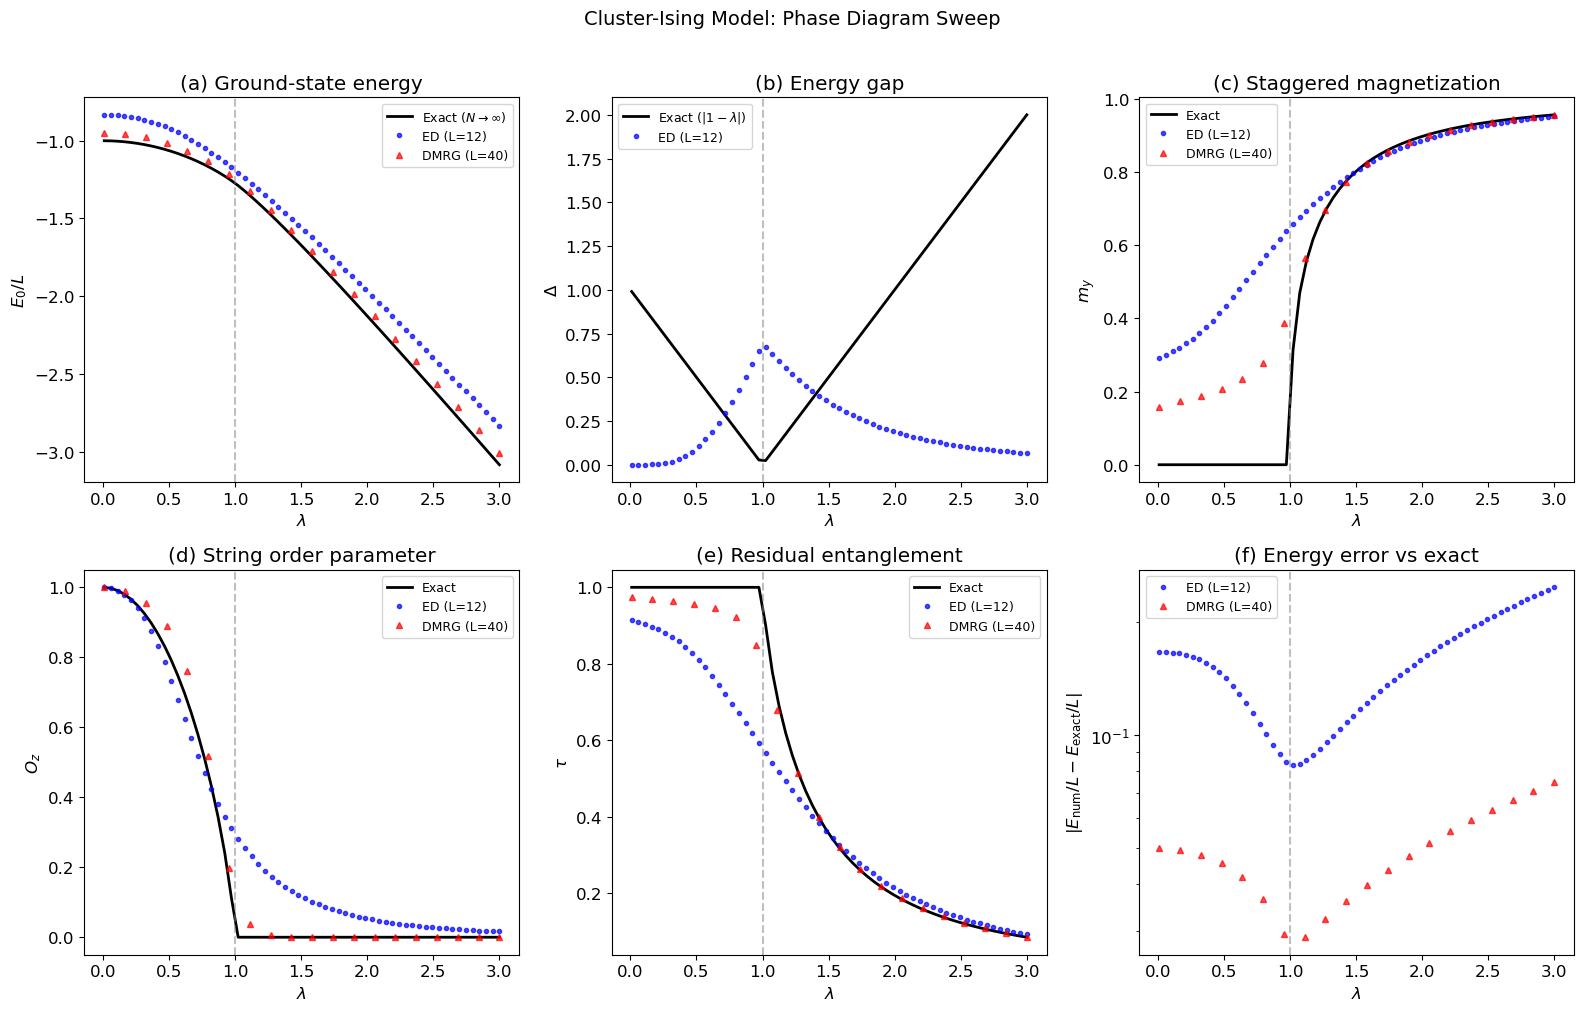

Saved: phase_diagram.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# --- (a) Ground-state energy per site ---
ax = axes[0, 0]
ax.plot(lam_values, E_exact, 'k-', lw=2, label='Exact ($N\\to\\infty$)')
ax.plot(lam_values, E_ed, 'bo', ms=3, alpha=0.7, label=f'ED (L={L_ed})')
if E_dmrg is not None:
    ax.plot(lam_dmrg, E_dmrg, 'r^', ms=4, alpha=0.7, label=f'DMRG (L={L_dmrg})')
ax.set_xlabel('$\\lambda$')
ax.set_ylabel('$E_0 / L$')
ax.set_title('(a) Ground-state energy')
ax.legend(fontsize=9)
ax.axvline(1.0, color='gray', ls='--', alpha=0.5)

# --- (b) Energy gap ---
ax = axes[0, 1]
ax.plot(lam_values, gap_exact, 'k-', lw=2, label='Exact ($|1-\\lambda|$)')
ax.plot(lam_values, gap_ed, 'bo', ms=3, alpha=0.7, label=f'ED (L={L_ed})')
ax.set_xlabel('$\\lambda$')
ax.set_ylabel('$\\Delta$')
ax.set_title('(b) Energy gap')
ax.legend(fontsize=9)
ax.axvline(1.0, color='gray', ls='--', alpha=0.5)

# --- (c) Staggered magnetization ---
ax = axes[0, 2]
ax.plot(lam_values, ops_exact['m_y'], 'k-', lw=2, label='Exact')
ax.plot(lam_values, my_ed, 'bo', ms=3, alpha=0.7, label=f'ED (L={L_ed})')
if my_dmrg is not None:
    ax.plot(lam_dmrg, my_dmrg, 'r^', ms=4, alpha=0.7, label=f'DMRG (L={L_dmrg})')
ax.set_xlabel('$\\lambda$')
ax.set_ylabel('$m_y$')
ax.set_title('(c) Staggered magnetization')
ax.legend(fontsize=9)
ax.axvline(1.0, color='gray', ls='--', alpha=0.5)

# --- (d) String order ---
ax = axes[1, 0]
ax.plot(lam_values, ops_exact['O_z'], 'k-', lw=2, label='Exact')
ax.plot(lam_values, Oz_ed, 'bo', ms=3, alpha=0.7, label=f'ED (L={L_ed})')
if Oz_dmrg is not None:
    ax.plot(lam_dmrg, Oz_dmrg, 'r^', ms=4, alpha=0.7, label=f'DMRG (L={L_dmrg})')
ax.set_xlabel('$\\lambda$')
ax.set_ylabel('$O_z$')
ax.set_title('(d) String order parameter')
ax.legend(fontsize=9)
ax.axvline(1.0, color='gray', ls='--', alpha=0.5)

# --- (e) Residual entanglement ---
ax = axes[1, 1]
ax.plot(lam_values, ops_exact['tau'], 'k-', lw=2, label='Exact')
ax.plot(lam_values, tau_ed, 'bo', ms=3, alpha=0.7, label=f'ED (L={L_ed})')
if tau_dmrg is not None:
    ax.plot(lam_dmrg, tau_dmrg, 'r^', ms=4, alpha=0.7, label=f'DMRG (L={L_dmrg})')
ax.set_xlabel('$\\lambda$')
ax.set_ylabel('$\\tau$')
ax.set_title('(e) Residual entanglement')
ax.legend(fontsize=9)
ax.axvline(1.0, color='gray', ls='--', alpha=0.5)

# --- (f) Energy error ---
ax = axes[1, 2]
E_exact_at_ed = energy_vs_lambda(lam_values)
ax.semilogy(lam_values, np.abs(E_ed - E_exact_at_ed), 'bo', ms=3, alpha=0.7,
            label=f'ED (L={L_ed})')
if E_dmrg is not None:
    E_exact_at_dmrg = energy_vs_lambda(lam_dmrg)
    ax.semilogy(lam_dmrg, np.abs(E_dmrg - E_exact_at_dmrg) + 1e-16, 'r^', ms=4,
               alpha=0.7, label=f'DMRG (L={L_dmrg})')
ax.set_xlabel('$\\lambda$')
ax.set_ylabel('$|E_{\\mathrm{num}}/L - E_{\\mathrm{exact}}/L|$')
ax.set_title('(f) Energy error vs exact')
ax.legend(fontsize=9)
ax.axvline(1.0, color='gray', ls='--', alpha=0.5)

fig.suptitle('Cluster-Ising Model: Phase Diagram Sweep', fontsize=14, y=1.01)
fig.tight_layout()
plt.savefig('phase_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: phase_diagram.png")

## 5. Detailed comparison table (at selected lambda values)

In [6]:
check_lambdas = [0.3, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 2.5]

print(f"{'lambda':>7s} | {'E_exact':>10s} {'E_ED':>10s} {'dE':>10s} | "
      f"{'m_y_ex':>8s} {'m_y_ED':>8s} | {'O_z_ex':>8s} {'O_z_ED':>8s}")
print('-' * 95)

for lam in check_lambdas:
    # Find closest index in lam_values
    idx = np.argmin(np.abs(lam_values - lam))
    e_ex = E_exact[idx]
    e_ed_val = E_ed[idx]
    my_ex = ops_exact['m_y'][idx]
    Oz_ex = ops_exact['O_z'][idx]
    
    print(f"{lam_values[idx]:7.3f} | {e_ex:10.6f} {e_ed_val:10.6f} {abs(e_ed_val-e_ex):10.2e} | "
          f"{my_ex:8.5f} {my_ed[idx]:8.5f} | {Oz_ex:8.5f} {Oz_ed[idx]:8.5f}")

 lambda |    E_exact       E_ED         dE |   m_y_ex   m_y_ED |   O_z_ex   O_z_ED
-----------------------------------------------------------------------------------------------
  0.314 |  -1.024816  -0.865821   1.59e-01 |  0.00000  0.35970 |  0.92507  0.91134
  0.517 |  -1.067963  -0.926527   1.41e-01 |  0.00000  0.43532 |  0.79214  0.73334
  0.821 |  -1.177224  -1.076824   1.00e-01 |  0.00000  0.57428 |  0.43164  0.42309
  1.024 |  -1.288704  -1.205497   8.32e-02 |  0.31388  0.65811 |  0.00000  0.28153
  1.176 |  -1.400409  -1.311789   8.86e-02 |  0.61743  0.71234 |  0.00000  0.20937
  1.480 |  -1.654121  -1.541568   1.13e-01 |  0.79547  0.79819 |  0.00000  0.12066
  1.986 |  -2.114428  -1.955870   1.59e-01 |  0.89620  0.88520 |  0.00000  0.05460
  2.493 |  -2.594544  -2.390951   2.04e-01 |  0.93634  0.92923 |  0.00000  0.02835


## 6. Dispersion relation & single-particle spectrum

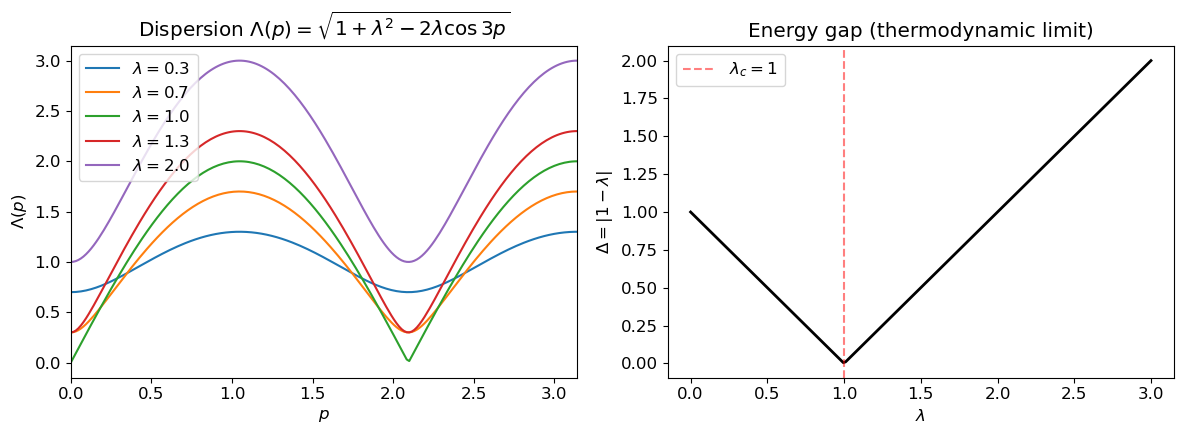

In [7]:
from cluster_ising.models.exact_solution import dispersion

p = np.linspace(0, np.pi, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Dispersion
ax = axes[0]
for lam in [0.3, 0.7, 1.0, 1.3, 2.0]:
    ax.plot(p, dispersion(p, lam), label=f'$\\lambda = {lam}$')
ax.set_xlabel('$p$')
ax.set_ylabel('$\\Lambda(p)$')
ax.set_title('Dispersion $\\Lambda(p) = \\sqrt{1+\\lambda^2 - 2\\lambda\\cos 3p}$')
ax.legend()
ax.set_xlim(0, np.pi)

# Energy gap vs lambda
ax = axes[1]
lam_fine = np.linspace(0, 3, 200)
ax.plot(lam_fine, [energy_gap(l) for l in lam_fine], 'k-', lw=2)
ax.set_xlabel('$\\lambda$')
ax.set_ylabel('$\\Delta = |1 - \\lambda|$')
ax.set_title('Energy gap (thermodynamic limit)')
ax.axvline(1.0, color='red', ls='--', alpha=0.5, label='$\\lambda_c = 1$')
ax.legend()

fig.tight_layout()
plt.show()